In [1]:
import requests
import pandas as pd
import time
from urllib.parse import quote

def fetch_priority_followed_papers_since_2020(output_file="data/priority_followed_data.csv"):
    base_url = f"https://api.openalex.org/works?filter=authorships.institutions.lineage%3Ai97018004%7Ci136199984%7Ci95457486%7Ci1291425158%7Ci4210090411%7Ci27837315%7Ci63966007%2Ctype%3Aarticle%2Cpublication_year%3A2020-"
    all_papers = []
    page = 1
    
    print("Starting to fetch priority followed papers since 2020...")
    
    while True:
        url = f"{base_url}&per_page=200&page={page}"
        response = requests.get(url)
        
        if response.status_code != 200:
            print(f"Error at page {page}: {response.status_code}")
            break
        
        data = response.json()
        results = data.get('results', [])
        
        if not results:
            break
        
        for work in results:
            all_papers.append(work)
            
        print(f"Page {page} fetched. Total papers: {len(all_papers)}")

        if len(results) < 200:
            break
        
        page += 1
        time.sleep(0.1)

    df = pd.DataFrame(all_papers)
    df.to_csv(output_file, index=False, encoding="utf-8")
    print(f"\nCompleted! Total {len(df)} papers saved to {output_file}")

            
def fetch_all_boun_papers(output_file="data/boun_corpus.csv"):
    # Use canonical BOUN ID from openalex_client (Boğaziçi University)
    base_url = f"https://api.openalex.org/works?filter=type%3Aarticle%2Cpublication_year%3A2020-%2Cauthorships.institutions.lineage%3Ai4405392"
    
    all_papers = []
    page = 1
    
    print("Starting to fetch BOUN corpus...")
    
    while True:
        url = f"{base_url}&per_page=200&page={page}"
        response = requests.get(url)
        
        if response.status_code != 200:
            print(f"Error at page {page}: {response.status_code}")
            break
            
        data = response.json()
        results = data.get('results', [])
        
        if not results:
            break
            
        for work in results:
            all_papers.append(work)
            
        print(f"Page {page} fetched. Total papers: {len(all_papers)}")
        
        if len(results) < 200:
            break
        
        page += 1
        time.sleep(0.1)

    df = pd.DataFrame(all_papers)
    df.to_csv(output_file, index=False, encoding="utf-8")
    print(f"\nCompleted! Total {len(df)} papers saved to {output_file}")

# if __name__ == "__main__":
    # fetch_all_boun_papers("data/boun_corpus_since_2020.csv")
    # fetch_priority_followed_papers_since_2020("data/priority_followed_data_since_2020.csv")


In [2]:
import json
import pandas as pd
import ast
import numpy as np

print("🚀 Creating BOUN vs Followed Institutions Performance Dataset")

# 1. Get BOUN papers
print("📥 Loading BOUN papers from CSV...")
boun_data = pd.read_csv("data/boun_corpus_since_2020.csv")
print(f"📊 Loaded {len(boun_data)} BOUN papers from CSV")

def parse_column(x):
    if pd.isna(x):
        return None
    
    if isinstance(x, str):
        x = x.strip()
        if x.startswith("{") or x.startswith("["):
            try:
                return ast.literal_eval(x)
            except:
                return x
    return x


for col in boun_data.columns:
    boun_data[col] = boun_data[col].map(parse_column)

boun_data.sample(10)


🚀 Creating BOUN vs Followed Institutions Performance Dataset
📥 Loading BOUN papers from CSV...
📊 Loaded 5038 BOUN papers from CSV


,id,doi,title,display_name,publication_year,publication_date,ids,language,primary_location,type,...,funders,has_content,content_urls,referenced_works_count,referenced_works,related_works,abstract_inverted_index,counts_by_year,updated_date,created_date
4652,https://openalex.org/W4414490930,https://doi.org/10.4401/ag-9317,Monitoring and Station Health of Türkiye – KOE...,Monitoring and Station Health of Türkiye – KOE...,2025,2025-09-25,{'openalex': 'https://openalex.org/W4414490930...,en,"{'id': 'doi:10.4401/ag-9317', 'is_oa': True, '...",article,...,[],"{'grobid_xml': False, 'pdf': True}",{'pdf': 'https://content.openalex.org/works/W4...,0,[],[],"{'The': [0, 143], 'Kandilli': [1], 'Observator...",[],2026-03-07T16:01:11.037858,2025-10-10T00:00:00
4250,https://openalex.org/W4401696885,https://doi.org/10.1149/ma2024-017807mtgabs,High-Performance Lithium-Sulfur Batteries with...,High-Performance Lithium-Sulfur Batteries with...,2024,2024-08-09,{'openalex': 'https://openalex.org/W4401696885...,en,"{'id': 'doi:10.1149/ma2024-017807mtgabs', 'is_...",article,...,[],"{'grobid_xml': False, 'pdf': False}",None,0,[],"[https://openalex.org/W1990428035, https://ope...","{'Lithium-sulfur': [0], '(Li-S)': [1], 'batter...",[],2025-12-26T23:08:49.675405,2025-10-10T00:00:00
1924,https://openalex.org/W4390539216,https://doi.org/10.1002/app.55121,Characterization and comparative evaluation of...,Characterization and comparative evaluation of...,2024,2024-01-03,{'openalex': 'https://openalex.org/W4390539216...,en,"{'id': 'doi:10.1002/app.55121', 'is_oa': True,...",article,...,"[{'id': 'https://openalex.org/F4320322626', 'd...","{'pdf': True, 'grobid_xml': False}",{'pdf': 'https://content.openalex.org/works/W4...,50,"[https://openalex.org/W96903077, https://opena...","[https://openalex.org/W2399277887, https://ope...","{'Abstract': [0], 'Blood': [1], 'oxygenators':...","[{'year': 2025, 'cited_by_count': 5}, {'year':...",2026-01-22T23:29:09.771500,2025-10-10T00:00:00
861,https://openalex.org/W4328048321,https://doi.org/10.1007/s11701-023-01558-2,Robotic male and laparoscopic female sphincter...,Robotic male and laparoscopic female sphincter...,2023,2023-03-21,{'openalex': 'https://openalex.org/W4328048321...,en,"{'id': 'doi:10.1007/s11701-023-01558-2', 'is_o...",article,...,[],"{'pdf': False, 'grobid_xml': False}",None,44,"[https://openalex.org/W89170657, https://opena...","[https://openalex.org/W3025039939, https://ope...",None,"[{'year': 2026, 'cited_by_count': 1}, {'year':...",2026-01-21T23:30:37.877113,2025-10-10T00:00:00
4047,https://openalex.org/W4386855234,https://doi.org/10.1149/ma2023-015882mtgabs,Assessment of Na-Ion Battery Performance Using...,Assessment of Na-Ion Battery Performance Using...,2023,2023-08-28,{'openalex': 'https://openalex.org/W4386855234...,en,"{'id': 'doi:10.1149/ma2023-015882mtgabs', 'is_...",article,...,[],"{'grobid_xml': False, 'pdf': False}",None,0,[],"[https://openalex.org/W2140186469, https://ope...","{'In': [0, 59, 131, 205, 286, 339], 'the': [1,...",[],2025-11-06T03:46:38.306776,2025-10-10T00:00:00
370,https://openalex.org/W3159242556,https://doi.org/10.1177/13548166211014367,Board diversity and firm risk-taking in the to...,Board diversity and firm risk-taking in the to...,2021,2021-05-06,{'openalex': 'https://openalex.org/W3159242556...,en,"{'id': 'doi:10.1177/13548166211014367', 'is_oa...",article,...,[],"{'pdf': False, 'grobid_xml': False}",None,78,"[https://openalex.org/W156977812, https://open...","[https://openalex.org/W2391061603, https://ope...","{'This': [0], 'study': [1], 'examines': [2], '...","[{'year': 2026, 'cited_by_count': 2}, {'year':...",2025-11-06T03:46:38.306776,2025-10-10T00:00:00
2640,https://openalex.org/W4401687275,https://doi.org/10.1103/physrevd.110.032015,Calibration of a soft secondary vertex tagger ...,Calibration of a soft secondary vertex tagger ...,2024,2024-08-19,{'openalex': 'https://openalex.org/W4401687275...,en,"{'id': 'doi:10.1103/physrevd.110.032015', 'is_...",article,...,"[

In [3]:
from collections import Counter
import re
import html

# reconstruct abstract from OpenAlex inverted index
def reconstruct_abstract(inv_index):
    if not isinstance(inv_index, dict):
        return None

    words = []

    for word, positions in inv_index.items():
        for pos in positions:
            words.append((pos, word))

    words = sorted(words)
    text = " ".join([w[1] for w in words])

    return text


# clean abstract text
def clean_abstract(text):

    if not isinstance(text, str):
        return None

    # decode HTML entities (&amp;lt; -> <)
    text = html.unescape(text)

    # remove HTML tags
    text = re.sub(r"<.*?>", "", text)

    # remove urls
    text = re.sub(r"http\S+", "", text)

    # remove extra spaces
    text = re.sub(r"\s+", " ", text)

    # remove ABSTRACT and Abstract words
    text = re.sub(r"\bABSTRACT\b", "", text)
    text = re.sub(r"\bAbstract\b", "", text)
    
    return text.strip()


# keyword extraction
def extract_keywords(text, n=10):

    words = re.findall(r"\b[a-zA-Z]+\b", text.lower())

    stopwords = {
        "the","and","of","to","in","a","for","on","with","is","are",
        "this","that","these","those","from","using","used","based",
        "study","paper","results","method","analysis"
    }

    words = [w for w in words if w not in stopwords and len(w) > 3]

    return [w for w,_ in Counter(words).most_common(n)]


# clean individual word
def clean_word(word):

    word = html.unescape(word)
    word = re.sub(r"<.*?>", "", word)
    word = re.sub(r"[^\w\s]", "", word)
    word = word.lower()

    if len(word) < 3:
        return None

    return word


# word frequency extraction
def word_freq_clean(inv_index):

    if not isinstance(inv_index, dict):
        return None

    freq = {}

    for word, positions in inv_index.items():

        clean = clean_word(word)

        if not clean:
            continue

        freq[clean] = len(positions)

    return freq


In [4]:

print("🔄 Processing BOUN papers to standard format...")


# sort papers
boun_data = boun_data.sort_values(by="publication_year", ascending=False)

# only English papers
boun_since_2020 = boun_data[boun_data["language"] == "en"].copy()


# reconstruct abstract
boun_since_2020["abstract_raw"] = (
    boun_since_2020["abstract_inverted_index"]
    .apply(reconstruct_abstract)
)


# clean abstract
boun_since_2020["abstract"] = (
    boun_since_2020["abstract_raw"]
    .apply(clean_abstract)
)


# word count
boun_since_2020["abstract_word_count"] = (
    boun_since_2020["abstract"]
    .apply(lambda x: len(x.split()) if isinstance(x,str) else None)
)


# keywords
boun_since_2020["abstract_keywords"] = (
    boun_since_2020["abstract"]
    .apply(lambda x: extract_keywords(x) if isinstance(x,str) else None)
)


# word frequencies
boun_since_2020["word_frequency"] = (
    boun_since_2020["abstract_inverted_index"]
    .apply(word_freq_clean)
)

🔄 Processing BOUN papers to standard format...


In [5]:
all_keywords = Counter()

for kws in boun_since_2020["abstract_keywords"].dropna():
    all_keywords.update(kws)

all_keywords.most_common(20)

boun_since_2020

,id,doi,title,display_name,publication_year,publication_date,ids,language,primary_location,type,...,related_works,abstract_inverted_index,counts_by_year,updated_date,created_date,abstract_raw,abstract,abstract_word_count,abstract_keywords,word_frequency
5037,https://openalex.org/W7134201305,https://doi.org/10.17275/per.26.24.13.2,Investigation of Social and Cultural Informal ...,Investigation of Social and Cultural Informal ...,2026,2026-03-08,{'openalex': 'https://openalex.org/W7134201305...,en,"{'id': 'doi:10.17275/per.26.24.13.2', 'is_oa':...",article,...,[],"{'This': [0], 'study': [1], 'aims': [2], 'to':...",[],2026-03-10T16:38:18.471706,2026-03-09T00:00:00,This study aims to investigate the social and ...,This study aims to investigate the social and ...,252.0,"[students, were, preferences, activities, cult...","{'this': 1, 'study': 1, 'aims': 1, 'investigat..."
4933,https://openalex.org/W7125368247,https://doi.org/10.1007/s10857-025-09739-6,How can teachers learn to teach effectively an...,How can teachers learn to teach effectively an...,2026,2026-01-22,{'openalex': 'https://openalex.org/W7125368247...,en,"{'id': 'doi:10.1007/s10857-025-09739-6', 'is_o...",article,...,[],None,[],2026-01-26T23:06:41.788003,2026-01-23T00:00:00,NaN,NaN,NaN,None,None
4934,https://openalex.org/W7125377449,https://doi.org/10.1002/bse.70489,Rethinking ESG‐Financial Performance Nexus Bey...,Rethinking ESG‐Financial Performance Nexus Bey...,2026,2026-01-21,{'openalex': 'https://openalex.org/W7125377449...,en,"{'id': 'doi:10.1002/bse.70489', 'is_oa': False...",article,...,[],"{'ABSTRACT': [0], 'Pressures': [1], 'to': [2, ...",[],2026-03-06T13:50:29.536080,2026-01-23T00:00:00,ABSTRACT Pressures to reconcile both sustainab...,Pressures to reconcile both sustainability com...,137.0,"[financial, esgp, firms, performance, scores, ...","{'abstract': 1, 'pressures': 1, 'reconcile': 1..."
4935,https://openalex.org/W7125416384,https://doi.org/10.1080/00368121.2026.2615961,Computational thinking meets robotics: using m...,Computational thinking meets robotics: using m...,2026,2026-01-21,{'openalex': 'https://openalex.org/W7125416384...,en,"{'id': 'doi:10.1080/00368121.2026.2615961', 'i...",article,...,[],None,[],2026-01-23T23:24:52.574035,2026-01-23T00:00:00,NaN,NaN,NaN,None,None
4936,https://openalex.org/W7125475576,https://doi.org/10.1051/0004-6361/202556086,Massive runaway star HD 254577: The pre-supern...,Massive runaway star HD 254577: The pre-supern...,2026,2026-01-21,{'openalex': 'https://openalex.org/W7125475576...,en,"{'id': 'doi:10.1051/0004-6361/202556086', 'is_...",article,...,[],"{'Aims.': [0], 'The': [1, 212, 317], 'secondar...",[],2026-03-10T16:38:18.471706,2026-01-24T00:00:00,Aims. The secondaries of massive binary system...,Aims. The secondaries of massive binary system...,356.0,"[star, runaway, binary, progenitor, massive, s...","{'aims': 1, 'the': 27, 'secondaries': 1, 'mass..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
917,https://openalex.org/W3012378318,https://doi.org/10.1007/s10915-020-01189-x,Galerkin Boundary Element Methods for High-Fre...,Galerkin Boundary Element Methods for High-Fre...,2020,2020-03-16,{'openalex': 'https://openalex.org/W3012378318...,en,"{'id': 'doi:10.1007/s10915-020-01189-x', 'is_o...",article,...,"[https://openalex.org/W3148450583, https://ope...",None,"[{'year': 2025, 'cited_by_count': 8}, {'year':...",2025-11-06T03:46:38.306776,2025-10-10T00:00:00,NaN,NaN,NaN,None,None
916,https://openalex.org/W3011218215,https://doi.org/10.1016/j.cep.2020.107914,Strategies for improving CO2 utilization in mi...,Strategies for improving CO2 utilization in mi...,2020,2020-03-19,{'openalex': 'https://openalex.org/W3011218215...,en,"{'id': 'doi:10.1016/j.cep.2020.107914', 'is_oa...",article,...,"[https://openalex.org/W2071527063, https://ope...",None,"[{'year': 2026, 'cited_by_count': 1}, {'year':...",2025-11-06T03:46:38.306776,2025-10-10T00:00:00,NaN,NaN,NaN,None,None
915,https:

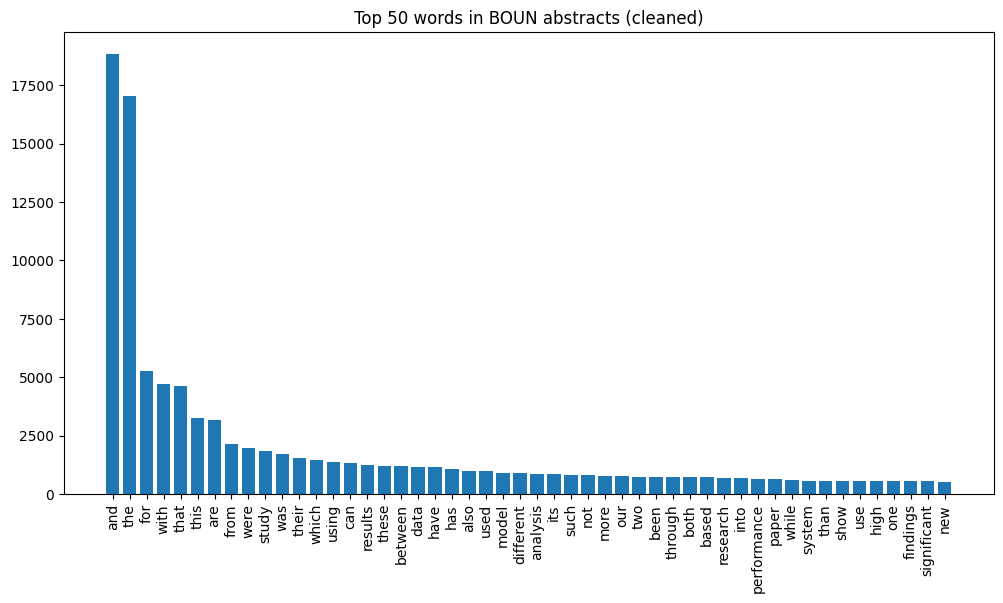

In [6]:
import matplotlib.pyplot as plt

overall_freq = Counter()
for wf in boun_since_2020["word_frequency"].dropna():
    overall_freq.update(wf)

most_common = overall_freq.most_common(50)

words, counts = zip(*most_common)

plt.figure(figsize=(12,6))
plt.bar(words, counts)
plt.xticks(rotation=90)
plt.title("Top 50 words in BOUN abstracts (cleaned)")
plt.show()

In [7]:
print("📥 Loading other papers from CSV...")
priority_followed_data = pd.read_csv("data/priority_followed_data_since_2020.csv")
print(f"📊 Loaded {len(priority_followed_data)} priority followed papers from CSV")

def parse_column(x):
    if pd.isna(x):
        return None
    
    if isinstance(x, str):
        x = x.strip()
        if x.startswith("{") or x.startswith("["):
            try:
                return ast.literal_eval(x)
            except:
                return x
    return x

for col in priority_followed_data.columns:
    priority_followed_data[col] = priority_followed_data[col].map(parse_column)

priority_papers = priority_followed_data.copy()
priority_papers.head()

📥 Loading other papers from CSV...
📊 Loaded 10000 priority followed papers from CSV


,id,doi,title,display_name,publication_year,publication_date,ids,language,primary_location,type,...,funders,has_content,content_urls,referenced_works_count,referenced_works,related_works,abstract_inverted_index,counts_by_year,updated_date,created_date
0,https://openalex.org/W3118615836,https://doi.org/10.1136/bmj.n71,The PRISMA 2020 statement: an updated guidelin...,The PRISMA 2020 statement: an updated guidelin...,2021,2021-03-29,{'openalex': 'https://openalex.org/W3118615836...,en,"{'id': 'doi:10.1136/bmj.n71', 'is_oa': True, '...",article,...,[],"{'grobid_xml': True, 'pdf': True}",{'pdf': 'https://content.openalex.org/works/W3...,79,"[https://openalex.org/W118549185, https://open...","[https://openalex.org/W4234875088, https://ope...","{'The': [0, 53, 78], 'Preferred': [1], 'Report...","[{'year': 2026, 'cited_by_count': 5226}, {'yea...",2026-03-10T16:38:18.471706,2025-10-10T00:00:00
1,https://openalex.org/W3177828909,https://doi.org/10.1038/s41586-021-03819-2,Highly accurate protein structure prediction w...,Highly accurate protein structure prediction w...,2021,2021-07-15,{'openalex': 'https://openalex.org/W3177828909...,en,"{'id': 'doi:10.1038/s41586-021-03819-2', 'is_o...",article,...,"[{'id': 'https://openalex.org/F4320317153', 'd...","{'grobid_xml': True, 'pdf': False}",{'grobid_xml': 'https://content.openalex.org/w...,89,"[https://openalex.org/W1589812083, https://ope...","[https://openalex.org/W2411998238, https://ope...",None,"[{'year': 2026, 'cited_by_count': 1658}, {'yea...",2026-03-10T16:38:18.471706,2021-07-19T00:00:00
2,https://openalex.org/W3003257820,https://doi.org/10.1038/s41592-019-0686-2,SciPy 1.0: fundamental algorithms for scientif...,SciPy 1.0: fundamental algorithms for scientif...,2020,2020-02-03,{'openalex': 'https://openalex.org/W3003257820...,en,"{'id': 'doi:10.1038/s41592-019-0686-2', 'is_oa...",article,...,"[{'id': 'https://openalex.org/F4320334632', 'd...","{'grobid_xml': True, 'pdf': True}",{'pdf': 'https://content.openalex.org/works/W3...,70,"[https://openalex.org/W147998453, https://open...",[],None,"[{'year': 2026, 'cited_by_count': 1459}, {'yea...",2026-03-10T16:38:18.471706,2020-02-07T00:00:00
3,https://openalex.org/W3035965352,https://doi.org/10.1038/s41586-020-2649-2,Array programming with NumPy,Array programming with NumPy,2020,2020-09-16,{'openalex': 'https://openalex.org/W3035965352...,en,"{'id': 'doi:10.1038/s41586-020-2649-2', 'is_oa...",article,...,"[{'id': 'https://openalex.org/F4320306151', 'd...","{'grobid_xml': True, 'pdf': True}",{'pdf': 'https://content.openalex.org/works/W3...,41,"[https://openalex.org/W1969761972, https://ope...",[],None,"[{'year': 2026, 'cited_by_count': 994}, {'year...",2026-03-10T16:38:18.471706,2020-06-25T00:00:00
4,https://openalex.org/W3164692211,https://doi.org/10.1016/j.cell.2021.04.048,Integrated analysis of multimodal single-cell ...,Integrated analysis of multimodal single-cell ...,2021,2021-05-31,{'openalex': 'https://openalex.org/W3164692211...,en,"{'id': 'doi:10.1016/j.cell.2021.04.048', 'is_o...",article,...,"[{'id': 'https://openalex.org/F4320306137', 'd...","{'grobid_xml': True, 'pdf': True}",{'pdf': 'https://content.openalex.org/works/W3...,104,"[https://openalex.org/W312480887, https://open...","[https://openalex.org/W2360935227, https://ope...",None,"[{'year': 2026, 'cited_by_count': 652}, {'year...",2026-03-10T16:38:18.471706,2021-06-07T00:00:00


In [8]:
print("🔄 Processing other papers to standard format...")

# sort papers
priority_papers = priority_papers.sort_values(by="publication_year", ascending=False)

# only English papers
priority_papers = priority_papers[priority_papers["language"] == "en"].copy()


# reconstruct abstract
priority_papers["abstract_raw"] = (
    priority_papers["abstract_inverted_index"]
    .apply(reconstruct_abstract)
)


# clean abstract
priority_papers["abstract"] = (
    priority_papers["abstract_raw"]
    .apply(clean_abstract)
)


# word count
priority_papers["abstract_word_count"] = (
    priority_papers["abstract"]
    .apply(lambda x: len(x.split()) if isinstance(x,str) else None)
)


# keywords
priority_papers["abstract_keywords"] = (
    priority_papers["abstract"]
    .apply(lambda x: extract_keywords(x) if isinstance(x,str) else None)
)


# word frequencies
priority_papers["word_frequency"] = (
    priority_papers["abstract_inverted_index"]
    .apply(word_freq_clean)
)

🔄 Processing other papers to standard format...


In [9]:
priority_papers

,id,doi,title,display_name,publication_year,publication_date,ids,language,primary_location,type,...,related_works,abstract_inverted_index,counts_by_year,updated_date,created_date,abstract_raw,abstract,abstract_word_count,abstract_keywords,word_frequency
367,https://openalex.org/W1498342204,https://doi.org/10.1145/3788687,An Introduction to Input/Output Automata,An Introduction to Input/Output Automata,2026,2026-01-27,{'openalex': 'https://openalex.org/W1498342204...,en,"{'id': 'doi:10.1145/3788687', 'is_oa': True, '...",article,...,"[https://openalex.org/W3144368627, https://ope...","{'We': [0, 15], 'describe': [1], 'the': [2, 17...","[{'year': 2024, 'cited_by_count': 2}, {'year':...",2026-03-08T08:50:53.379069,2016-06-24T00:00:00,"We describe the input/output automaton model, ...","We describe the input/output automaton model, ...",44.0,"[model, describe, input, output, automaton, co...","{'describe': 1, 'the': 5, 'inputoutput': 1, 'a..."
6720,https://openalex.org/W4406633044,https://doi.org/10.1038/s41562-024-02090-5,Trust in scientists and their role in society ...,Trust in scientists and their role in society ...,2025,2025-01-20,{'openalex': 'https://openalex.org/W4406633044...,en,"{'id': 'doi:10.1038/s41562-024-02090-5', 'is_o...",article,...,"[https://openalex.org/W2560936962, https://ope...","{'Science': [0], 'is': [1, 99], 'crucial': [2]...","[{'year': 2026, 'cited_by_count': 31}, {'year'...",2026-03-10T16:38:18.471706,2025-10-10T00:00:00,Science is crucial for evidence-based decision...,Science is crucial for evidence-based decision...,147.0,"[scientists, trust, evidence, science, decisio...","{'science': 1, 'crucial': 1, 'for': 2, 'eviden..."
6203,https://openalex.org/W4413972333,https://doi.org/10.1177/10507256251363120,2025 American Thyroid Association Management G...,2025 American Thyroid Association Management G...,2025,2025-08-01,{'openalex': 'https://openalex.org/W4413972333...,en,"{'id': 'doi:10.1177/10507256251363120', 'is_oa...",article,...,"[https://openalex.org/W2899084033, https://ope...","{'<b><i>Background:</i></b>': [0], 'Differenti...","[{'year': 2026, 'cited_by_count': 92}, {'year'...",2026-03-10T16:38:18.471706,2025-10-10T00:00:00,<b><i>Background:</i></b> Differentiated thyro...,Background: Differentiated thyroid cancer (DTC...,349.0,"[guidelines, thyroid, cancer, patients, were, ...","{'background': 1, 'differentiated': 1, 'thyroi..."
965,https://openalex.org/W4410611457,https://doi.org/10.70389/pjs.100079,Revised Surgical CAse REport (SCARE) Guideline...,Revised Surgical CAse REport (SCARE) Guideline...,2025,2025-05-22,{'openalex': 'https://openalex.org/W4410611457...,en,"{'id': 'doi:10.70389/pjs.100079', 'is_oa': Tru...",article,...,"[https://openalex.org/W4391375266, https://ope...","{'INTRODUCTION': [0], 'Artificial': [1], 'inte...","[{'year': 2026, 'cited_by_count': 32}, {'year'...",2026-03-08T08:50:53.379069,2025-05-23T00:00:00,INTRODUCTION Artificial intelligence (AI) is r...,INTRODUCTION Artificial intelligence (AI) is r...,228.0,"[scare, consensus, items, update, surgical, ca...","{'introduction': 1, 'artificial': 1, 'intellig..."
6910,https://openalex.org/W4406426717,https://doi.org/10.1038/s43586-024-00373-9,Perovskite solar cells,Perovskite solar cells,2025,2025-01-16,{'openalex': 'https://openalex.org/W4406426717...,en,"{'id': 'doi:10.1038/s43586-024-00373-9', 'is_o...",article,...,"[https://openalex.org/W2899084033, https://ope...",None,"[{'year': 2026, 'cited_by_count': 38}, {'year'...",2026-03-07T16:01:11.037858,2025-10-10T00:00:00,NaN,NaN,NaN,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2788,https://openalex.org/W3011813593,https://doi.org/10.1038/s41467-020-14887-9,Fiber reinforced GelMA hydrogel to induce the ...,Fiber reinforced GelMA hydrogel to induce the ...,2020,2020-03-18,{'openalex': 'https://openalex.org/W3011813593...,en,"{'id': 'doi:10.1038/s41467-020-14887-9', 'is_o...",article,...,"[https://openalex.org/W2320363194

In [12]:
# save the cleaned data
priority_papers.to_csv("data/cleaned/priority_followed.csv", index=False)
boun_since_2020.to_csv("data/cleaned/boun.csv", index=False)
